<p align="center">
  <a href="https://vicena.ai"><strong>Built with Vicena</strong></a>
</p>

# Rowan product conformer analysis

This notebook is part of the Vicena Research Twins collection. It analyzes the saved Rowan cyclohexene conformer result without submitting a new job. The result supports product endpoint preparation only, not transition-state or reaction-path validation.

## Purpose and scientific status

Inputs are archived under `results/example/rowan/`. The notebook reports exact provider provenance, visualizes the returned molecular geometry, and states the mechanism-validation boundary. No Rowan submission call appears here.

In [5]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
raw = json.loads((ROOT / "results/example/rowan/product_conformer_raw.json").read_text())
prov = json.loads((ROOT / "results/example/rowan/workflow_provenance.json").read_text())
summary = pd.read_csv(ROOT / "results/example/rowan/summary.csv")

print("Workflow UUID:", prov["workflow_uuid"])
print("Status:", prov["status"])
print("Requested method:", prov["settings"]["final_method"])
print("Charge and multiplicity:", prov["input"]["charge"], prov["input"]["multiplicity"])
print("Rowan credits charged:", prov["budget"]["rowan_credits_charged"])
print("Conformers returned:", len(raw["energies"]))
print("Provider path energies[0]:", raw["energies"][0])
display(summary)

Workflow UUID: 3d530210-368d-4296-9460-94b383d7295a
Status: completed-ok
Requested method: aimnet2_wb97md3
Charge and multiplicity: 0 1
Rowan credits charged: 0.37
Conformers returned: 1
Provider path energies[0]: -234.80424401193108


,task_key,name,workflow_type,workflow_uuid,status,max_credits,result_path,failure_log_path,result_error,failure_phase,failure_kind
0,f43370cdba3ac6d039a29b05,Diels-Alder cyclohexene product conformers,conformer_search,3d530210-368d-4296-9460-94b383d7295a,completed-ok,1,/root/sessions/476_open-source-reaction-mechan...,NaN,NaN,NaN,NaN


In [6]:
props = pd.DataFrame(raw["conformer_properties"]).rename_axis("conformer_index")
display(props)
print("Radius of gyration:", props.loc[0, "radius_of_gyration"])
print("Solvent accessible surface area:", props.loc[0, "solvent_accessible_surface_area"])
print("Polar solvent accessible surface area:", props.loc[0, "polar_solvent_accessible_surface_area"])

,polar_solvent_accessible_surface_area,radius_of_gyration,solvent_accessible_surface_area
conformer_index,,,
0,0.0,1.584,262.643


Radius of gyration: 1.584
Solvent accessible surface area: 262.643
Polar solvent accessible surface area: 0.0


## Visual evidence

These panels are regenerated from bundled repository artifacts, without remote compute:

1. the declared Diels-Alder reaction,
2. the bonded cyclohexene conformer reconstructed from saved Rowan coordinates,
3. the archived synthetic pathway fixture, clearly separated from Rowan results.

The native interactive scene is `results/example/structures/product_rowan_conformer.molscene.json`.

Rowan workflow UUID: 3d530210-368d-4296-9460-94b383d7295a
Rowan credits charged: 0.37
Conformers returned: 1
Archived fixture activation energy (kcal/mol): 26.999285379266144
Generated reference-family PDF, PNG, reaction scheme, Rowan conformer, and archived profile


### Declared reaction

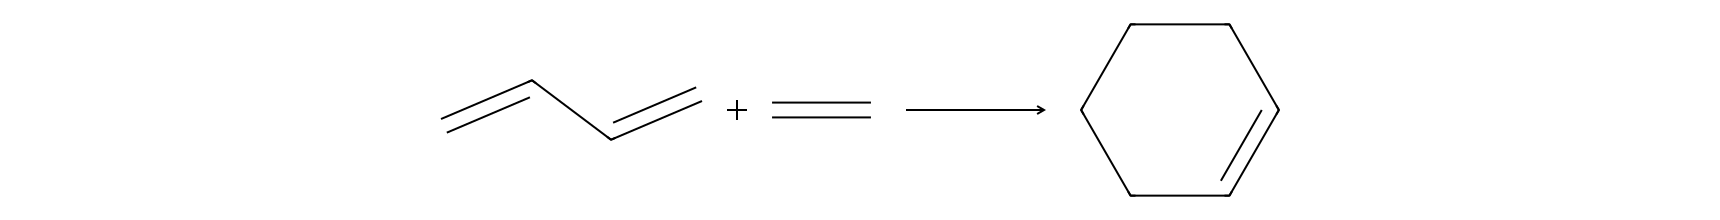

### Saved Rowan conformer, bonded rendering

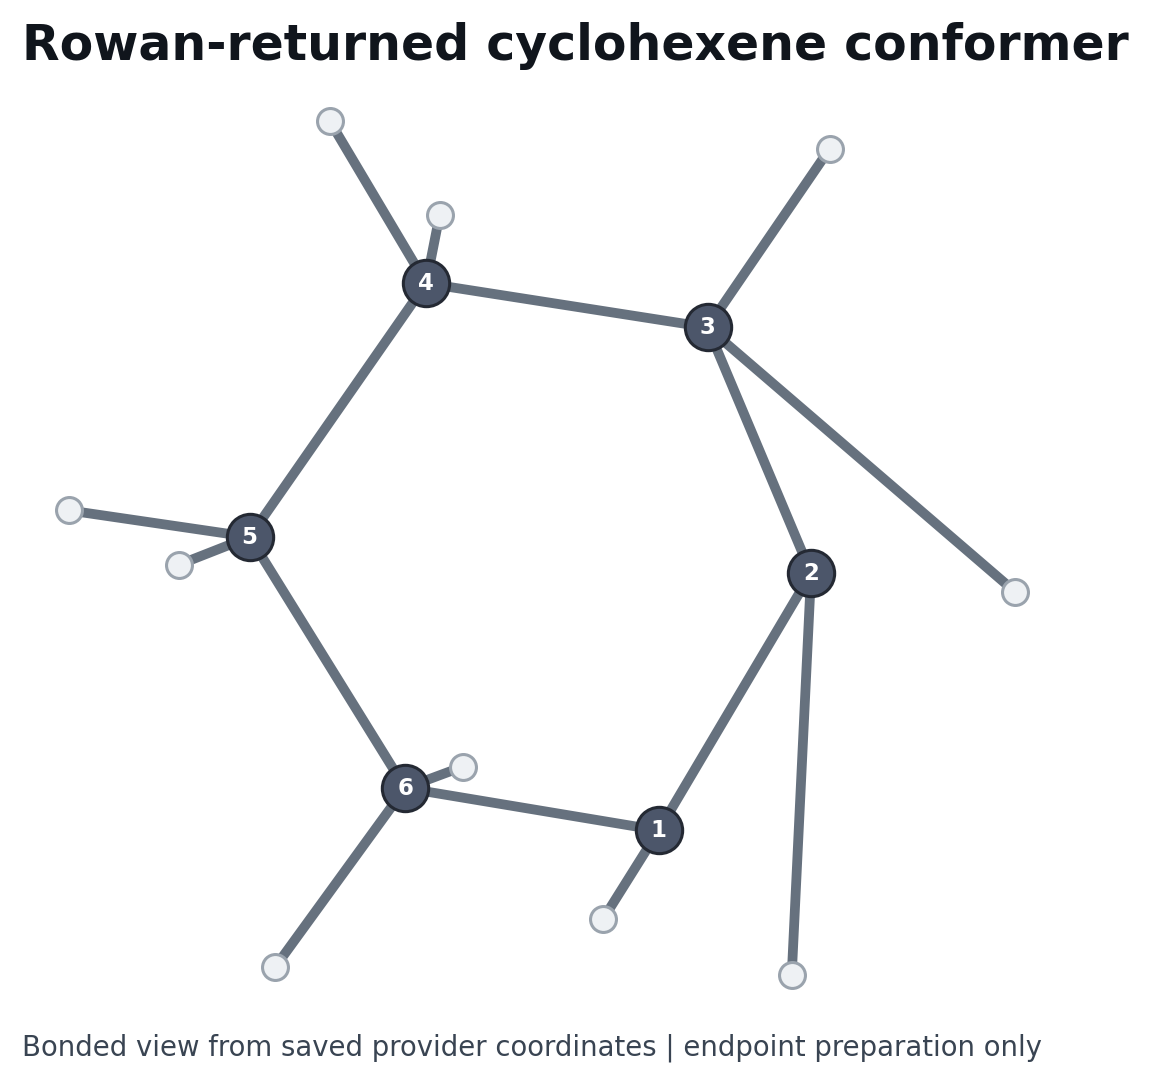

### Archived synthetic pathway fixture

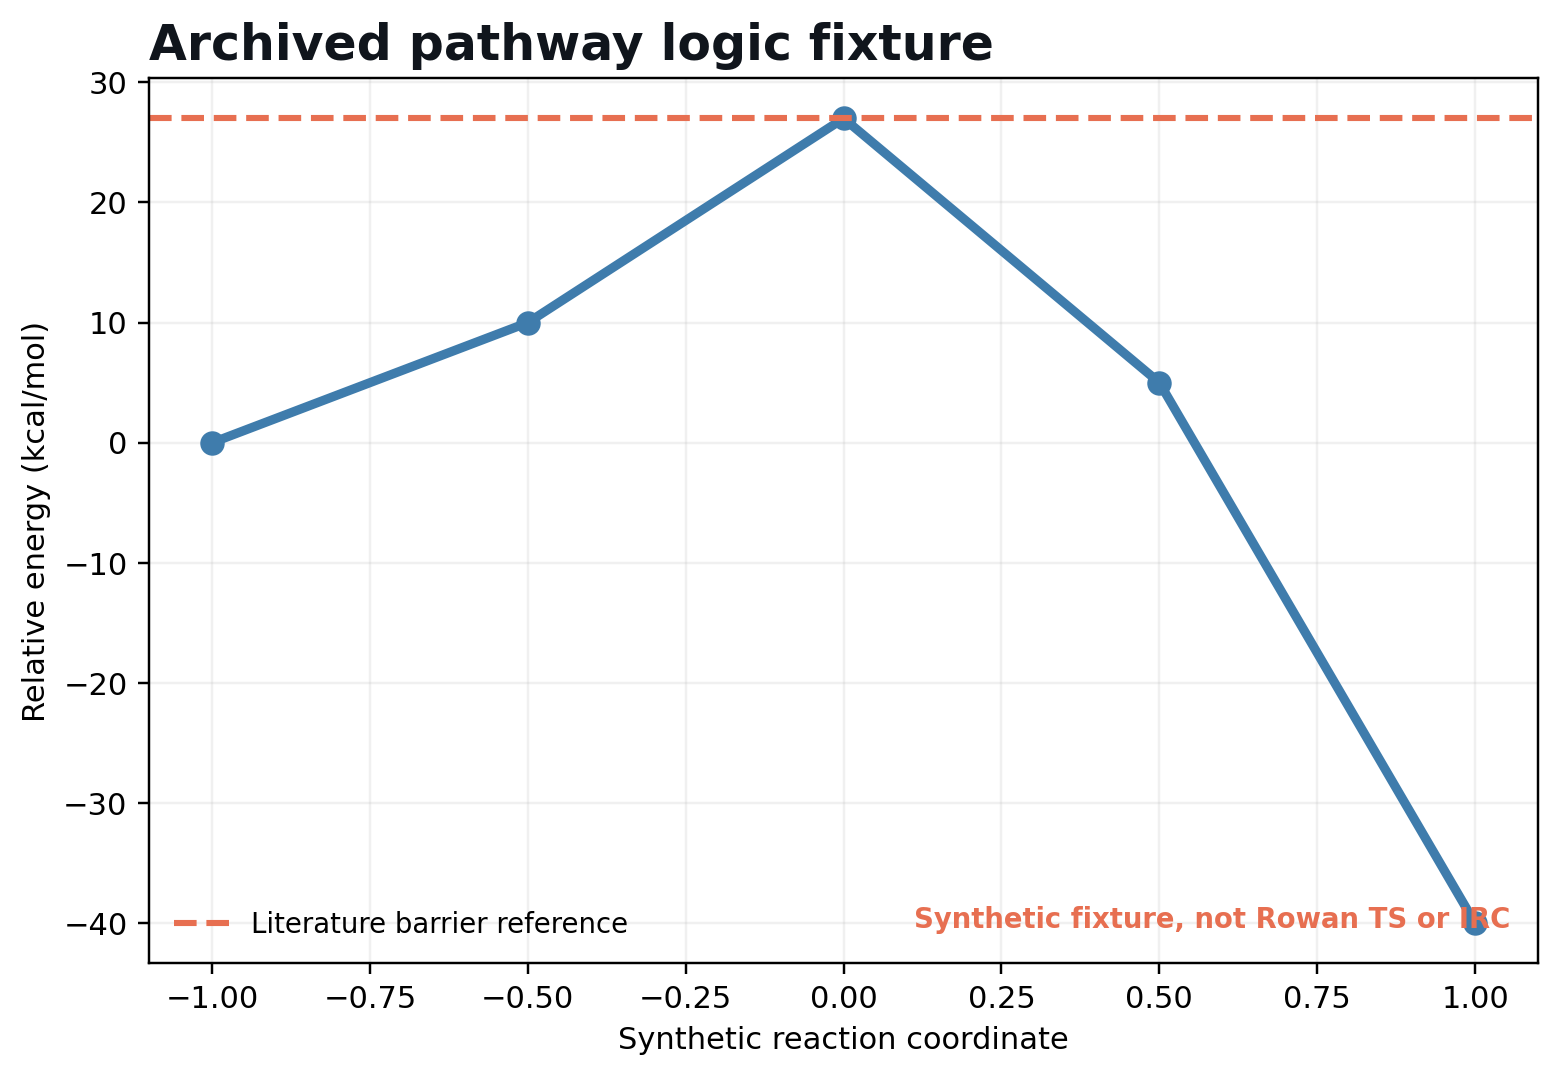

In [10]:
# Regenerate public visuals from bundled results, without remote compute.
%run ../scripts/generate_branded_assets.py

for title, filename in [
    ("Declared reaction", "reaction-scheme.png"),
    ("Saved Rowan conformer, bonded rendering", "rowan-cyclohexene-conformer.png"),
    ("Archived synthetic pathway fixture", "archived-energy-profile.png"),
]:
    display(Markdown(f"### {title}"))
    display(Image(filename=str(ROOT / "assets" / filename), width=760))

In [8]:
atoms = raw["initial_molecule"]["atoms"]
coords = pd.DataFrame([
    {"atom_index": i+1, "atomic_number": a["atomic_number"], "x_A": a["position"][0], "y_A": a["position"][1], "z_A": a["position"][2]}
    for i, a in enumerate(atoms)
])
display(coords)
print("Atom count:", len(coords))
print("Carbon atoms:", int((coords.atomic_number == 6).sum()))
print("Hydrogen atoms:", int((coords.atomic_number == 1).sum()))

,atom_index,atomic_number,x_A,y_A,z_A
0,1,6,0.707300,-1.288506,-0.294379
1,2,6,1.460863,-0.016555,-0.554189
2,3,6,0.948710,1.200281,-0.317483
3,4,6,-0.443782,1.417963,0.199044
4,5,6,-1.317165,0.163226,0.117397
5,6,6,-0.547639,-1.079332,0.557209
6,7,1,0.430760,-1.729435,-1.259480
7,8,1,1.365143,-2.005307,0.210023
8,9,1,2.469631,-0.107790,-0.949132
9,10,1,1.553147,2.084017,-0.506116


Atom count: 16
Carbon atoms: 6
Hydrogen atoms: 10


## Validation boundary

A conformer search prepares an endpoint geometry. It does not establish a reaction pathway. A mechanism claim still requires matched endpoints, a transition-state candidate, exactly one chemically relevant imaginary mode, displacement consistent with intended bond changes, plausible geometry, and IRC or equivalent connection evidence.

In [9]:
acceptance = pd.Series(prov["acceptance"], name="value")
display(acceptance.to_frame())
assert prov["acceptance"]["endpoint_conformer_collected"] is True
assert prov["acceptance"]["transition_state_validated"] is False
assert prov["acceptance"]["irc_validated"] is False
print("Conclusion: product endpoint preparation completed. Reaction pathway remains unvalidated.")

,value
endpoint_conformer_collected,True
reaction_path_validated,False
transition_state_validated,False
frequencies_validated,False
irc_validated,False
statement,This result supports product endpoint preparat...


Conclusion: product endpoint preparation completed. Reaction pathway remains unvalidated.
